# Network Perturbations: Leave-One-Out and Sequential Node Removal

Companion to `networks_random.ipynb`. Three graphs with the **same size and (nearly) the same mean degree**
are perturbed by deleting nodes, and the response of global quantities is measured.

1. **Leave-one-out (LOO):** delete each node once, recompute, record the change Δ.
2. **Sequential removal:** keep deleting nodes, either at random (*failure*) or hubs first (*attack*).

In [2]:
import networkx as nx
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize

plt.rcParams.update({
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'lines.linewidth': 2,
})


## The graphs

Density is matched: the ER edge probability is set to $p = \langle k \rangle / (N-1)$, so that topology rather than
edge count drives any difference. (With the original $p = 0.5$ the ER graph has more than twice the edges of the WS graph.)
A Barabási–Albert graph is added as a third case because its heavy-tailed degree distribution makes the attack/failure
contrast obvious. All generators are seeded for reproducibility.

In [3]:
N = 30
k = 6                    # target mean degree
p = k / (N - 1)          # ER edge probability matched to WS density  (try 0.5 to compare)
beta = 0.3               # WS rewiring probability
seed = 1234

graphs = {
    'ER': nx.erdos_renyi_graph(N, p, seed=seed),
    'WS': nx.watts_strogatz_graph(N, k, beta, seed=seed),
    'BA': nx.barabasi_albert_graph(N, k // 2, seed=seed),
}

layouts = {
    'ER': nx.spring_layout(graphs['ER'], seed=seed),
    'WS': nx.circular_layout(graphs['WS']),
    'BA': nx.spring_layout(graphs['BA'], seed=seed),
}

## Global quantities

`average_shortest_path_length` fails as soon as the graph is disconnected, so **global efficiency**
$E = \frac{1}{N(N-1)}\sum_{i\neq j} 1/d_{ij}$ is added: it behaves like an inverse path length but stays defined
(unreachable pairs contribute 0). The fraction of nodes in the largest connected component is also tracked.

In [4]:
def global_quantities(G):
    n = G.number_of_nodes()
    connected = n > 1 and nx.is_connected(G)
    giant = max((len(c) for c in nx.connected_components(G)), default=0)
    return {
        'mean degree': 2 * G.number_of_edges() / n if n else np.nan,
        'density': nx.density(G),
        'mean path length': nx.average_shortest_path_length(G) if connected else np.nan,
        'global efficiency': nx.global_efficiency(G),
        'giant component': giant / n if n else 0.0,
    }

baseline = pd.DataFrame({name: global_quantities(G) for name, G in graphs.items()}).T
baseline.round(3)

,mean degree,density,mean path length,global efficiency,giant component
ER,5.6,0.193,2.117,0.547,1.0
WS,6.0,0.207,2.067,0.558,1.0
BA,5.4,0.186,2.018,0.559,1.0


## 1. Leave-one-out

For every node $v$: remove it, recompute, store $\Delta Q_v = Q(G \setminus v) - Q(G)$.

In [5]:
def leave_one_out(G):
    base = global_quantities(G)
    btw = nx.betweenness_centrality(G)
    rows = []
    for v in G.nodes:
        H = G.copy()
        H.remove_node(v)
        q = global_quantities(H)
        rows.append({'node': v, 'degree': G.degree(v), 'betweenness': btw[v],
                     **{f'Δ {key}': q[key] - base[key] for key in base}})
    return pd.DataFrame(rows).set_index('node')

loo = {name: leave_one_out(G) for name, G in graphs.items()}

# the five most damaging single deletions in the WS graph
loo['WS'].sort_values('Δ global efficiency').head().round(4)

,degree,betweenness,Δ mean degree,Δ density,Δ mean path length,Δ global efficiency,Δ giant component
node,,,,,,,
29,10,0.1168,-0.4828,-0.0099,0.0663,-0.0141,0.0
20,7,0.0678,-0.2759,-0.0025,0.0417,-0.0078,0.0
26,7,0.0657,-0.2759,-0.0025,0.0417,-0.0076,0.0
24,7,0.0605,-0.2759,-0.0025,0.0294,-0.0057,0.0
5,7,0.0590,-0.2759,-0.0025,0.0294,-0.0057,0.0


### How large are the effects, and what predicts them?

In [6]:
summary = {}
for name, df in loo.items():
    b = baseline.loc[name]
    summary[name] = {
        'max |Δ MPL| (%)':            100 * df['Δ mean path length'].abs().max() / b['mean path length'],
        'max |Δ efficiency| (%)':     100 * df['Δ global efficiency'].abs().max() / b['global efficiency'],
        'corr(Δ density, degree)':    df['Δ density'].corr(df['degree']),
        'corr(Δ MPL, betweenness)':   df['Δ mean path length'].corr(df['betweenness']),
        'corr(Δ eff., betweenness)':  df['Δ global efficiency'].corr(df['betweenness']),
    }
pd.DataFrame(summary).T.round(3)

,max |Δ MPL| (%),max |Δ efficiency| (%),"corr(Δ density, degree)","corr(Δ MPL, betweenness)","corr(Δ eff., betweenness)"
ER,4.118,2.666,-1.0,0.934,-0.927
WS,3.210,2.531,-1.0,0.948,-0.956
BA,10.560,7.985,-1.0,0.981,-0.980


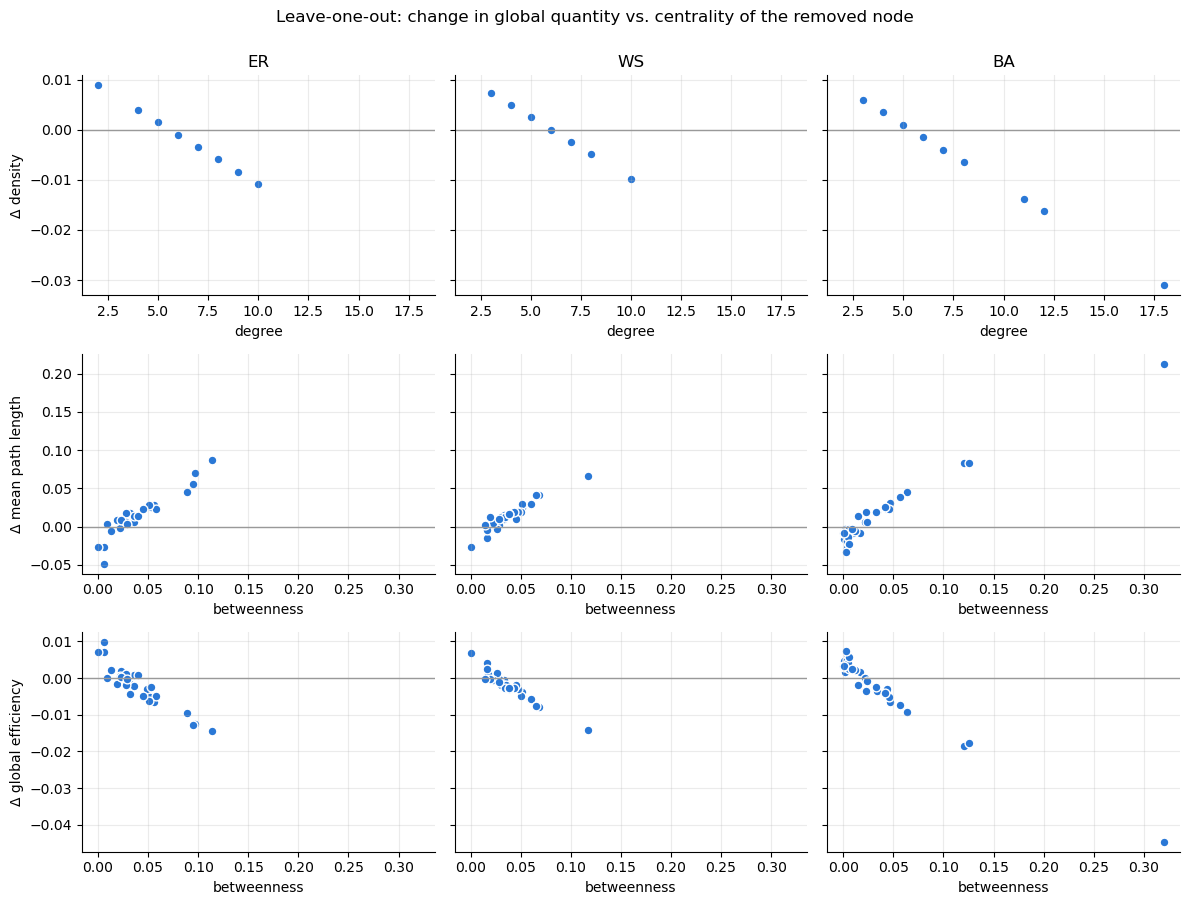

In [7]:
rows = [('degree', 'Δ density'),
        ('betweenness', 'Δ mean path length'),
        ('betweenness', 'Δ global efficiency')]

fig, axes = plt.subplots(len(rows), len(graphs), figsize=(12, 9), sharey='row', sharex='row')
for j, (name, df) in enumerate(loo.items()):
    for i, (x, y) in enumerate(rows):
        ax = axes[i, j]
        ax.axhline(0, color='0.6', lw=1)
        ax.scatter(df[x], df[y], s=40, color='#2a78d6', edgecolor='white', linewidth=1)
        if i == 0:
            ax.set_title(name)
        if j == 0:
            ax.set_ylabel(y)
        ax.set_xlabel(x)
fig.suptitle('Leave-one-out: change in global quantity vs. centrality of the removed node', y=1.0)
fig.tight_layout()

**Reading the plots**

* **Row 1 – density (and mean degree) is trivial.** Removing a node of degree $k_v$ gives exactly
  $\rho' = 2(M - k_v)/\big((N-1)(N-2)\big)$, a straight line in $k_v$ (correlation −1). LOO on these quantities
  only re-ranks nodes by degree. Note also $\langle k \rangle = \rho\,(N-1)$, so they are the same measurement.
* **Rows 2–3 – path-based quantities carry information.** The impact tracks betweenness, i.e. how many shortest paths
  run through the node. Effects are small (a few percent) in these dense-ish graphs.
* **Negative ΔMPL / positive ΔE** occur when a peripheral node is removed: its long paths leave the average.
  That is a normalisation effect, not an improvement of the network – worth pointing out to students.

### Impact map

Node colour = Δ global efficiency when that node is removed (red = loss), node size = degree.

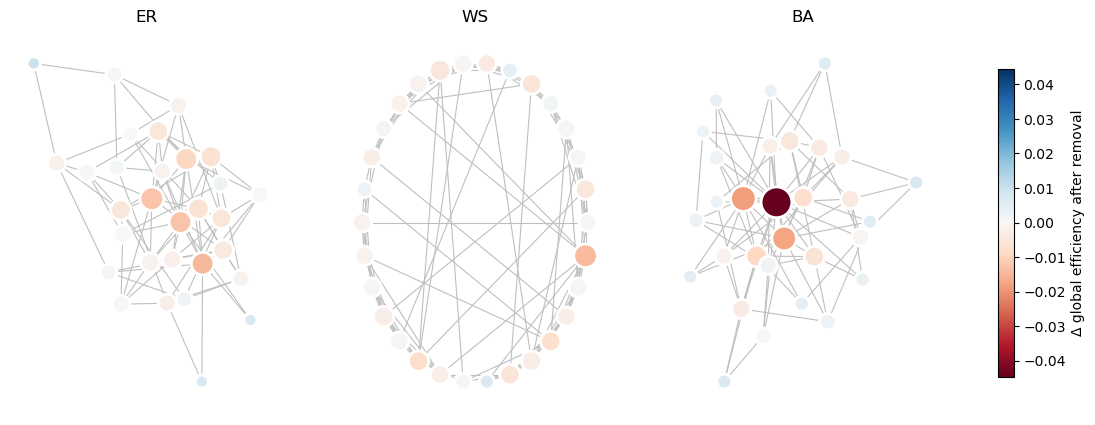

In [8]:
vabs = max(df['Δ global efficiency'].abs().max() for df in loo.values())
norm = Normalize(-vabs, vabs)
cmap = plt.cm.RdBu

fig, axes = plt.subplots(1, len(graphs), figsize=(15, 5))
for ax, (name, G) in zip(axes, graphs.items()):
    df = loo[name]
    nx.draw_networkx_edges(G, layouts[name], ax=ax, edge_color='0.75', width=0.8)
    nx.draw_networkx_nodes(G, layouts[name], ax=ax,
                           node_color=[cmap(norm(df.loc[v, 'Δ global efficiency'])) for v in G],
                           node_size=[40 + 25 * G.degree(v) for v in G],
                           edgecolors='white', linewidths=2)
    ax.set_title(name)
    ax.axis('off')
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=axes, shrink=0.8,
             label='Δ global efficiency after removal');

## 2. Sequential removal: failure vs. attack

Single deletions barely move these graphs. Removing nodes one after another separates them clearly.

* **random** – failure; averaged over many runs (band = 5–95 % range)
* **degree** – attack on the current highest-degree node (recomputed after each removal)
* **betweenness** – attack on the current highest-betweenness node

Tracked: size of the largest component and global efficiency, both relative to the intact graph. Efficiency is averaged
over the *original* $N(N-1)$ node pairs (removed nodes count as unreachable); otherwise a small surviving fragment
such as a single edge would have efficiency 1 and the curve would rise again.

In [9]:
def removal_curve(G, strategy, rng=None):
    H = G.copy()
    N0, E0 = G.number_of_nodes(), nx.global_efficiency(G)
    giant, eff = [1.0], [1.0]
    for _ in range(N0 - 1):
        if strategy == 'random':
            v = rng.choice(list(H.nodes))
        elif strategy == 'degree':
            v = max(H.degree, key=lambda x: x[1])[0]
        elif strategy == 'betweenness':
            b = nx.betweenness_centrality(H)
            v = max(b, key=b.get)
        H.remove_node(v)
        giant.append(max(len(c) for c in nx.connected_components(H)) / N0)
        n = H.number_of_nodes()
        # efficiency counted over the ORIGINAL N(N-1) pairs, so it can only decrease
        eff.append(nx.global_efficiency(H) * n * (n - 1) / (N0 * (N0 - 1)) / E0)
    return np.array(giant), np.array(eff)

n_random = 100
rng = np.random.default_rng(seed)
curves = {}
for name, G in graphs.items():
    rand = np.array([removal_curve(G, 'random', rng) for _ in range(n_random)])  # (runs, 2, N)
    curves[name] = {
        'random': rand,
        'degree': removal_curve(G, 'degree'),
        'betweenness': removal_curve(G, 'betweenness'),
    }

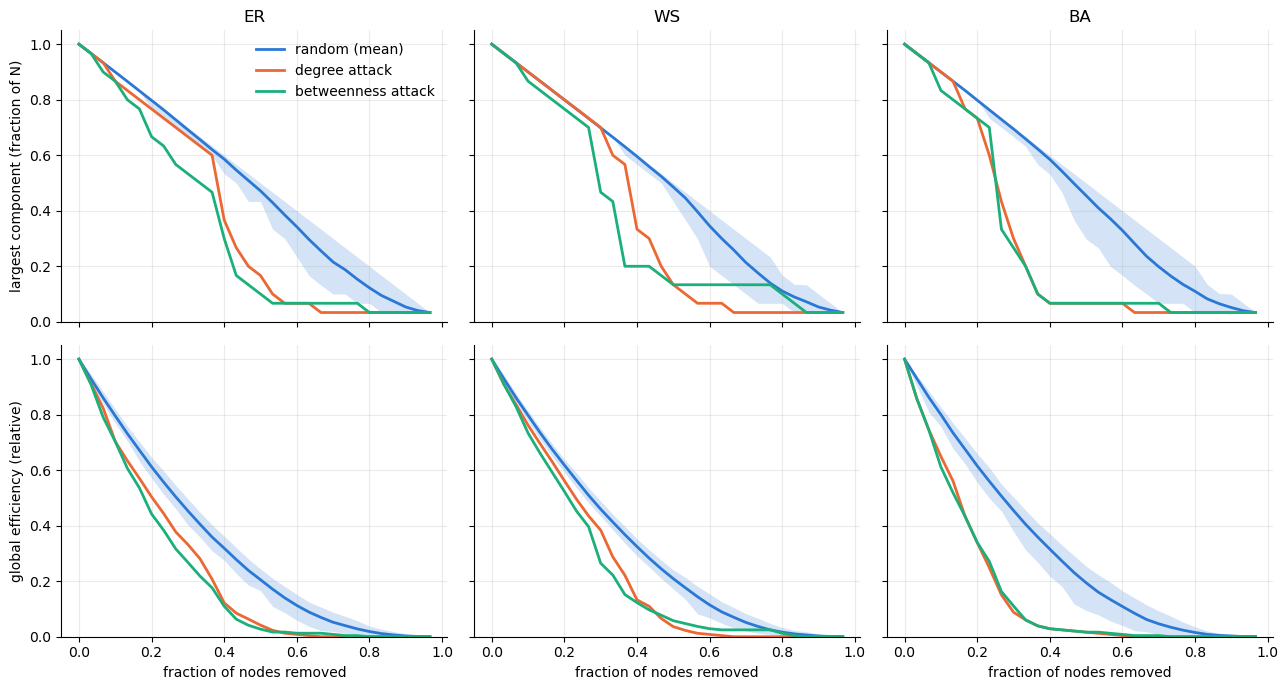

In [10]:
strategy_colors = {'random': '#2a78d6', 'degree': '#eb6834', 'betweenness': '#1baf7a'}
f = np.arange(N) / N          # fraction of nodes removed

fig, axes = plt.subplots(2, len(graphs), figsize=(13, 7), sharex=True, sharey='row')
for j, name in enumerate(graphs):
    for i, label in enumerate(['largest component (fraction of N)', 'global efficiency (relative)']):
        ax = axes[i, j]
        rand = curves[name]['random'][:, i, :]
        ax.fill_between(f, np.percentile(rand, 5, axis=0), np.percentile(rand, 95, axis=0),
                        color=strategy_colors['random'], alpha=0.2, lw=0)
        ax.plot(f, rand.mean(axis=0), color=strategy_colors['random'], label='random (mean)')
        for s in ['degree', 'betweenness']:
            ax.plot(f, curves[name][s][i], color=strategy_colors[s], label=f'{s} attack')
        ax.set_ylim(0, 1.05)
        if i == 0:
            ax.set_title(name)
        else:
            ax.set_xlabel('fraction of nodes removed')
        if j == 0:
            ax.set_ylabel(label)
axes[0, 0].legend(frameon=False)
fig.tight_layout()

### One number per graph: robustness $R$

To get back to a single global number per graph, integrate the largest-component curve:
$R = \frac{1}{N}\sum_{q} s(q)$ (Schneider et al., *PNAS* 2011). $R \approx 0.5$ is maximally robust,
small $R$ means the network falls apart quickly. The same can be done for the efficiency curve.

In [11]:
R = {}
for name, c in curves.items():
    R[name] = {
        'R random (giant)':       c['random'][:, 0, :].mean(),
        'R degree attack':        c['degree'][0].mean(),
        'R betweenness attack':   c['betweenness'][0].mean(),
        'R_E random (eff.)':      c['random'][:, 1, :].mean(),
        'R_E degree attack':      c['degree'][1].mean(),
    }
pd.DataFrame(R).T.round(3)

,R random (giant),R degree attack,R betweenness attack,R_E random (eff.),R_E degree attack
ER,0.485,0.371,0.337,0.322,0.238
WS,0.488,0.376,0.359,0.325,0.254
BA,0.478,0.288,0.286,0.320,0.176


## Things to try

* Set `p = 0.5` (the original ER graph): LOO effects shrink to ~1 % – dense graphs are robust to single deletions.
* Vary `beta` from 0 (ring lattice, all nodes equivalent → all LOO values identical) to 1 (random).
* Increase `N` to 200+: the attack/failure gap in the BA graph widens (use fewer random runs; betweenness attack gets slow).
* Edge perturbations: the edge analogue of LOO is removing each edge in turn; its impact tracks
  `nx.edge_betweenness_centrality`.